# 05-1 결정트리

## 1️⃣ 와인 데이터 준비

In [ ]:
import pandas as pd
wine =  pd.read_csv('./data/wine.csv')
wine.head()

# 알코올도수, 당도, ph, class ( 0이면 레드와인, 1이면 화이트와인)
# 전체 와인클래스에서 화이트와인을 골라내는 문제이다. (화이트와인이 양성클래스이므로)

,alcohol,sugar,pH,class
0,9.4,1.9,3.51,0.0
1,9.8,2.6,3.20,0.0
2,9.8,2.3,3.26,0.0
3,9.8,1.9,3.16,0.0
4,9.4,1.9,3.51,0.0


In [2]:
wine.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   alcohol  6497 non-null   float64
 1   sugar    6497 non-null   float64
 2   pH       6497 non-null   float64
 3   class    6497 non-null   float64
dtypes: float64(4)
memory usage: 203.2 KB


In [3]:
wine.describe()

,alcohol,sugar,pH,class
count,6497.000000,6497.000000,6497.000000,6497.000000
mean,10.491801,5.443235,3.218501,0.753886
std,1.192712,4.757804,0.160787,0.430779
min,8.000000,0.600000,2.720000,0.000000
25%,9.500000,1.800000,3.110000,1.000000
50%,10.300000,3.000000,3.210000,1.000000
75%,11.300000,8.100000,3.320000,1.000000
max,14.900000,65.800000,4.010000,1.000000


## 2️⃣ 데이터 분리

In [5]:
data = wine[['alcohol', 'sugar', 'pH']]
target = wine['class']

## 3️⃣ 훈련 데이터 / 테스트 데이터 분리

In [6]:
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(
    data, target, test_size=0.2, random_state=42)

In [7]:
#훈련 세트와 테스트 세트 크기 확인
print(train_input.shape, test_input.shape)

(5197, 3) (1300, 3)


## 4️⃣ 데이터 스케일링

- 로지스틱 회귀는 **특성의 크기에 영향을 받기 때문에** 스케일링이 필요하다.

In [8]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
ss.fit(train_input)

train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

## 5️⃣ 로지스틱 회귀 모델 훈련

In [9]:
#표준화된 점수로 로지스틱 회귀 모델 훈련
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(train_scaled, train_target)

print(lr.score(train_scaled, train_target))
print(lr.score(test_scaled, test_target))

0.7808350971714451
0.7776923076923077


## 7️⃣ 로지스틱 회귀의 계수 확인

In [19]:
wine.columns

Index(['alcohol', 'sugar', 'pH', 'class'], dtype='str')

In [20]:
print(lr.coef_, lr.intercept_)

[[ 0.51268071  1.67335441 -0.68775646]] [1.81773456]


In [ ]:
# 각 특성이 분류에 얼마나 영향을 미치는지 나타낸다.
# 아마도 알코올 도수와 당도가 높을수록 화이트와인일 가능성이 높고, 
# ph가 높을수록 레드와인일 확률이 높은것 같으나 설명하기 어려움

## 9️⃣ 결정트리 모델 만들기

In [21]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(train_scaled, train_target)

print(dt.score(train_scaled, train_target))
print(dt.score(test_scaled, test_target))


0.996921300750433
0.8592307692307692


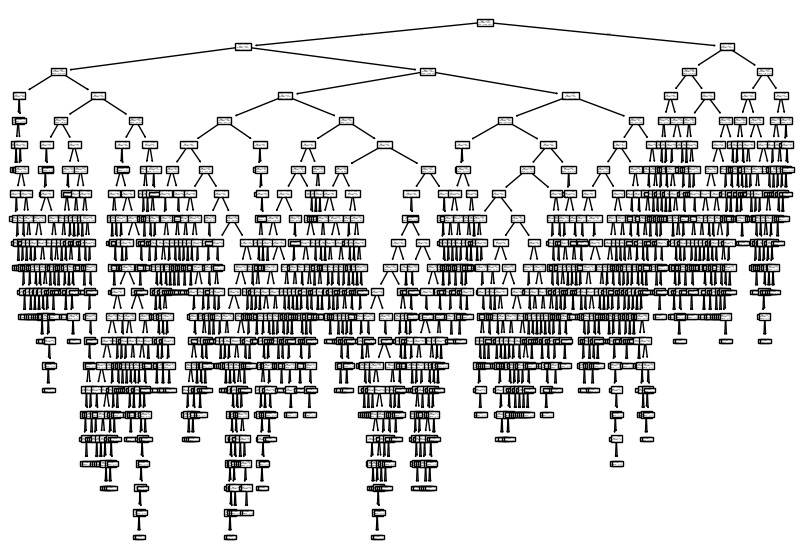

In [ ]:
#이 모델을 그림으로 표현해 보자

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize = (10,7))
plot_tree(dt)
plt.show()

# import 모듈
# → 모듈 전체 가져오기
# → 모듈이름.함수()

# from 모듈 import 함수
# → 특정 함수만 가져오기
# → 바로 사용 가능


In [ ]:
# 결정트리는 위에서 아래로 거꾸로 자라난다.
# 맨 위의 노드(node)를 루트노드(root node)라 부르고 맨 아래 끝에 달린 노드를 리프 노드(leaf node)라고 한다.

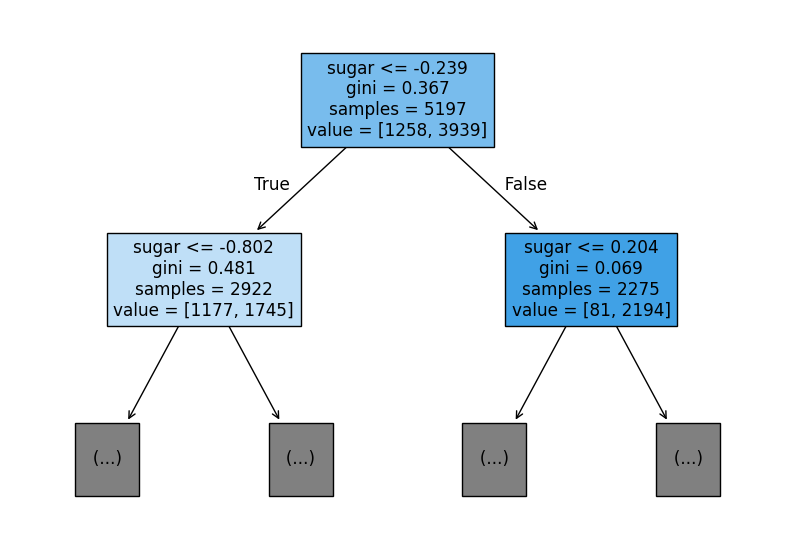

In [26]:
#너무 복잡하니 트리의 깊이를 제한해서 출력해 보자
plt.figure(figsize=(10,7))

plot_tree(dt, max_depth=1, filled=True, feature_names=['alcohol', 'sugar', 'pH'])
plt.show()

# max_depth=1로 주면 루트 노드를 제외하고 하나의 노드을 더 확장하여 그린다
# filled=True, 클래스에 맞게 색을 칠한다.(색으로 분류 표시)
# eature_names, 특성이름을 전달함

In [ ]:
# 당도(sugar) <= -0.239 이하인지 질문 ? 작거나 같으면 왼쪽, 그렇지 않으면 오른쪽
# 샘플수는 5,197개, 음성클래스(레드와인, 1258), 양성클래스(화이트와인, 3939)

# 두번째 오른쪽 루트를 보면 화이트와인(2194)로 훨씬 많음

In [ ]:
# 어떻게 당도(sugar) <= -0.239 이하인지 질문이 나왔을까? -0.239라는 숫자는?
# 이 알고리즘은 정보 이득이 최대가 되도록 데이터를 나눈다.

In [27]:
print(dt.feature_importances_)

[0.23101011 0.52164748 0.24734241]


In [ ]:
# 지니불순도 : 한 노드 안에 클래스가 얼마나 섞여 있는지
1-((1258/5197)**2+(3939/5197)**2)

# 클래스가 완전히 섞임	0.5
# 조금 섞임	0.3
# 거의 한쪽	0.1
# 완전히 하나 0

0.3669367279393918

In [ ]:
# 정보이득, 즉 불순도가 얼마나 줄었는가를 계산한다.
0.367-(2922/5197) * 0.481 - (2275/5197)*0.069 

0.06635405041370024

In [ ]:
# 결론 : 결정 트리 알고리즘 - 불순도 기준을 사용해 정보이득이 최대가 되도록 노드를 분할한다.

In [ ]:
# sklearn 구조 때문
# sklearn
#  ├─ linear_model
#  │   ├─ LogisticRegression
#  │   ├─ SGDClassifier
#  │
#  ├─ tree
#  │   ├─ DecisionTreeClassifier
#  │   ├─ plot_tree
#  │
#  ├─ neighbors
#  │   ├─ KNeighborsClassifier
#  │
#  ├─ svm
#  │   ├─ SVC

# import sklearn
# sklearn.linear_model.LogisticRegression()

# from sklearn.linear_model import LogisticRegression
# lr = LogisticRegression()

#### 가지치기

- 열매를 잘 맺기 위해 과수원에서 가지치기를 하는 것처럼 결정 트리도 가지치기를 해야 한다.
- 가지치기를 하지 않으면 훈련세트에는 아주 잘 맞겠지만 테스트 세트에서 점수는 그에 미치지 못하게 된다. => 일반화가 잘 안된 것
- 가지치기 방법 => 자라날 수 있는 트리의 최대 깊이를 지정한다.

In [32]:
#트리의 깊이를 3으로 지정
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(train_scaled, train_target)

print(dt.score(train_scaled, train_target))
print(dt.score(test_scaled, test_target))

0.8454877814123533
0.8415384615384616


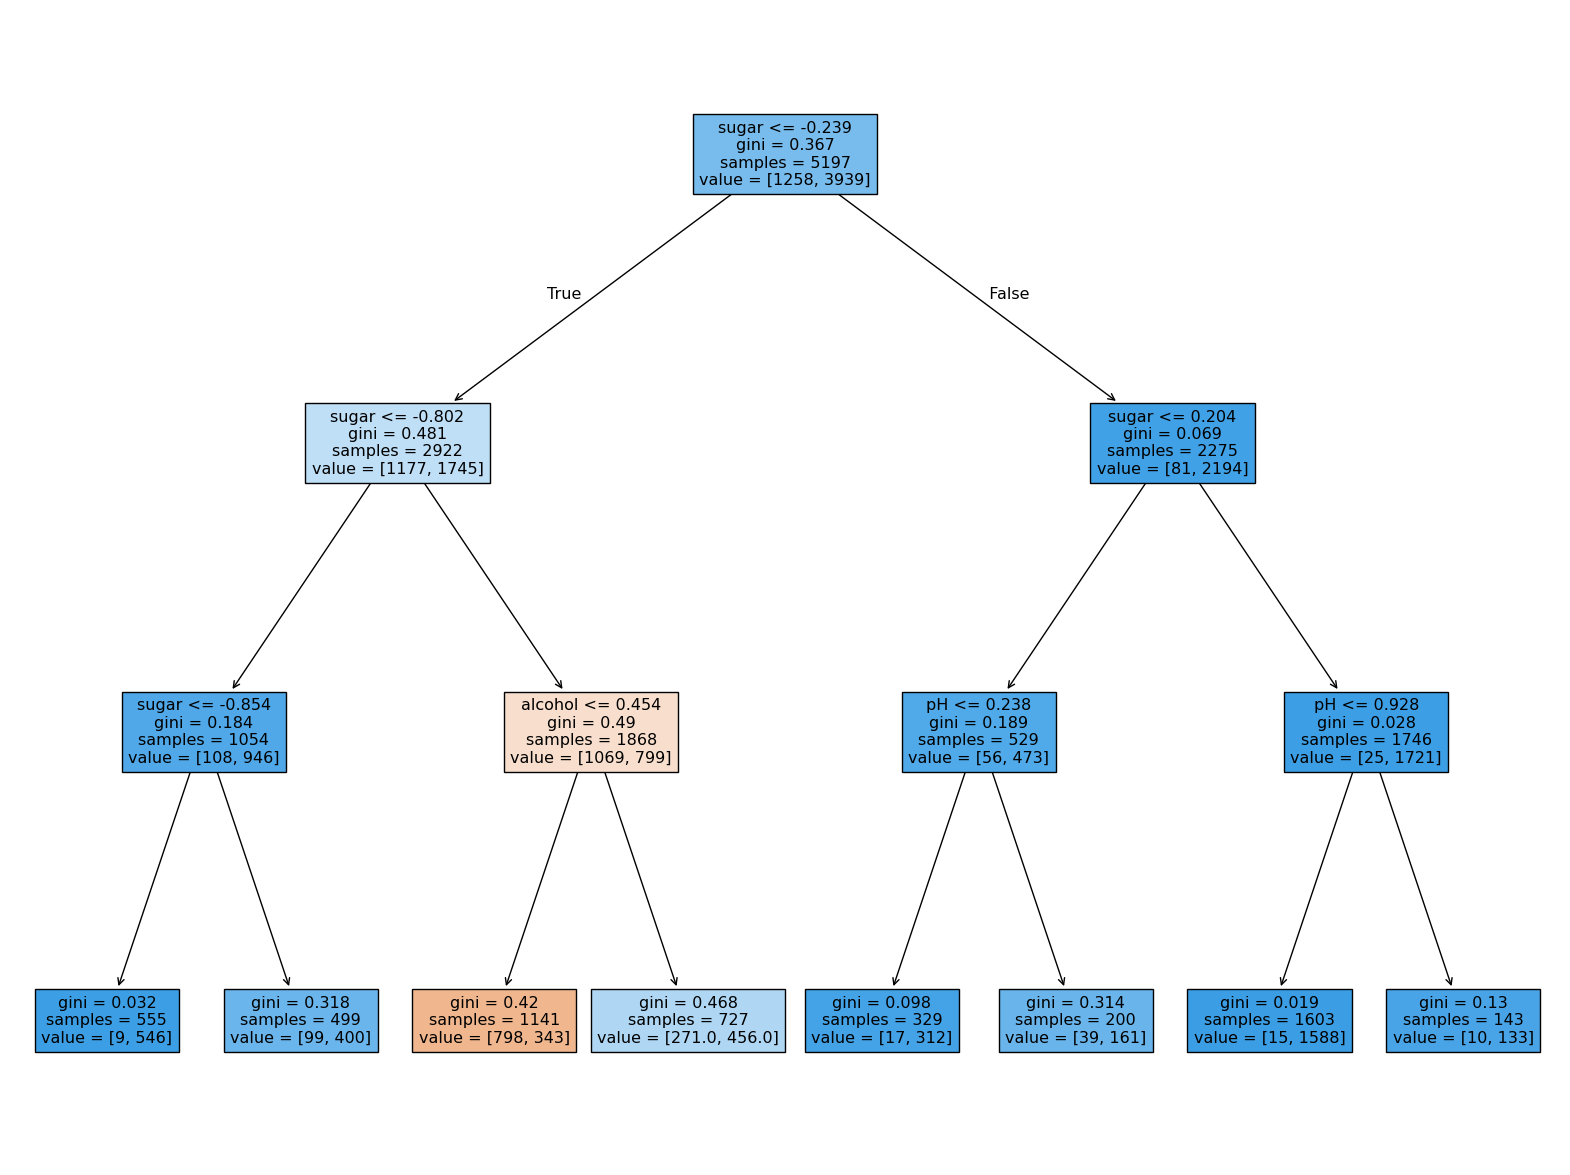

In [33]:
#트리를 만들어 보자
plt.figure(figsize=(20,15))
plot_tree(dt, filled=True, feature_names=['alcohol', 'sugar', 'pH'])
plt.show()

In [ ]:
# 불순도는 클래스별 비율을 가지고 계산하므로 특성값의 스케일이 계산에 영향을 미치지 않는다. 
# 전처리 과정이 필요 없다.

In [34]:
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(train_input, train_target)

print(dt.score(train_input, train_target))
print(dt.score(test_input, test_target))


0.8454877814123533
0.8415384615384616


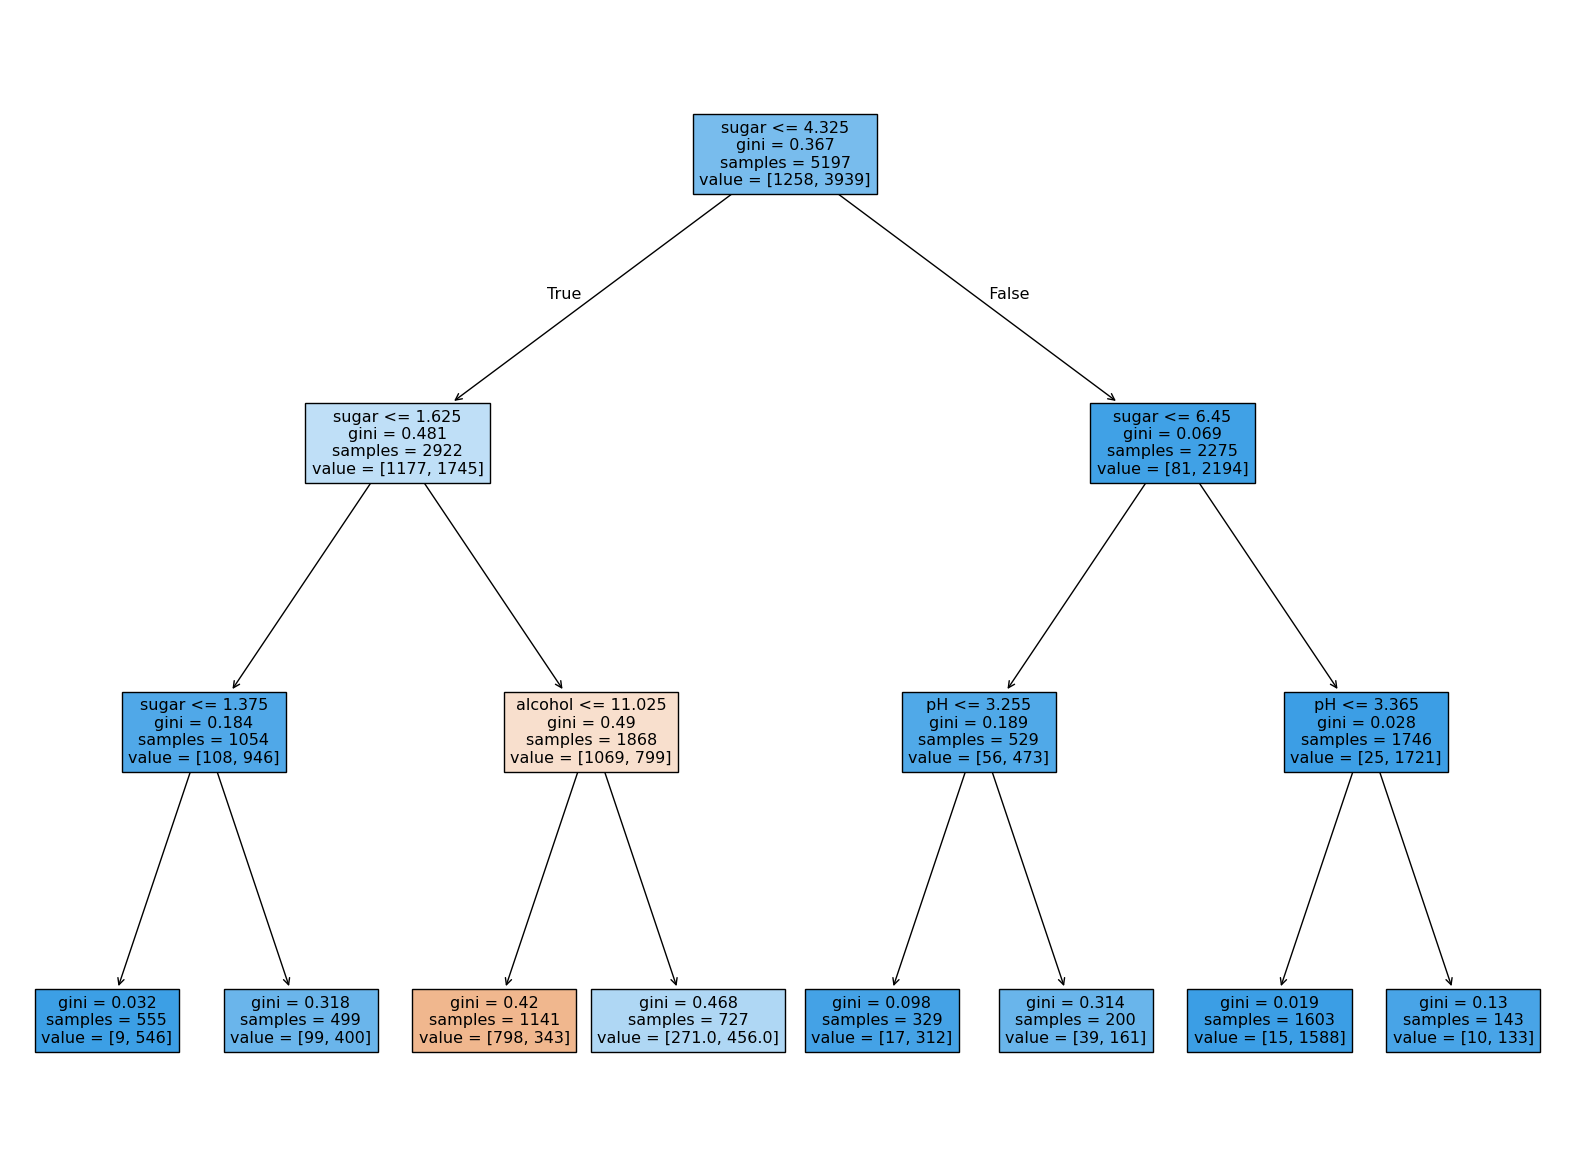

In [35]:
plt.figure(figsize=(20,15))
plot_tree(dt, filled=True, feature_names=['alcohol', 'sugar', 'pH'])
plt.show()

In [ ]:
# 예측
pred = dt.predict(test_input)

In [40]:
dt.score(test_input, test_target)

0.8415384615384616

In [43]:
pred[:10]

array([1., 0., 1., 1., 1., 1., 1., 1., 0., 1.])

In [44]:
test_target.values[:10]

array([1., 0., 1., 1., 1., 0., 1., 1., 0., 1.])